Does the scatter we observe in the TFR reduce when we use the NSA axis ratio instead of the SGA?

In [1]:
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
import astropy.units as u

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/')
# sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from line_fits import hyperfit_line

# Data

In [2]:
# Y1 TFR catalog
SGA_filename = '/Users/kdouglass/Documents/Research/data/DESI/Y1/DESI-DR1_TF_pv_cat_v15.fits'

# NSA
NSA_filename = '/Users/kdouglass/Documents/Drexel/Research/Data/NSA/nsa_v1_0_1.fits'

In [3]:
SGA = Table.read(SGA_filename, format='fits')
NSA = Table.read(NSA_filename, format='fits')

In [4]:
SGA_coords = SkyCoord(ra=SGA['RA']*u.degree, dec=SGA['DEC']*u.degree)
NSA_coords = SkyCoord(ra=NSA['RA']*u.degree, dec=NSA['DEC']*u.degree)

idx, d2d, d3d = SGA_coords.match_to_catalog_sky(NSA_coords)

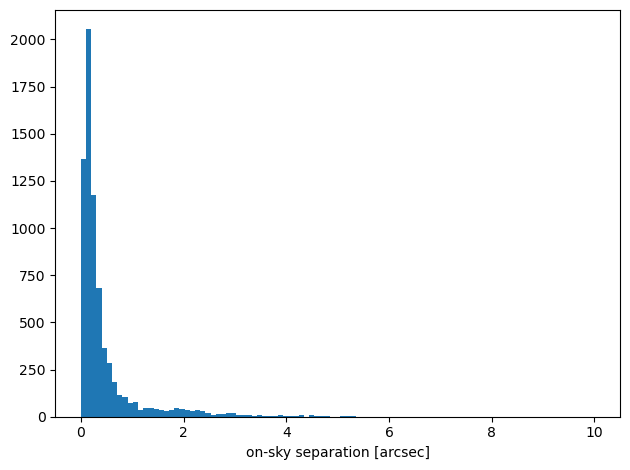

In [5]:
plt.figure(tight_layout=True)

plt.hist(d2d.to('arcsec'), bins=np.linspace(0,10,100)*u.arcsec)

plt.xlabel('on-sky separation [arcsec]');

In [6]:
good_match = d2d.to('arcsec') < 5*u.arcsec

SGA_m = SGA[good_match]
NSA_m = NSA[idx[good_match]]

In [9]:
# Remove any masked rows
bad_rows = NSA_m['ELPETRO_BA'].mask

SGA_matched = SGA_m[~bad_rows]
NSA_matched = NSA_m[~bad_rows]

# Recalculate $V(0.4R_{26})$

Use the NSA axis ratio instead of the SGA-2020

In [10]:
q0 = 0.2

cosi2_NSA = (NSA_matched['ELPETRO_BA']**2 - q0**2)/(1 - q0**2)
cosi2_NSA[cosi2_NSA < 0] = 0

cosi2_SGA = (SGA_matched['BA']**2 - q0**2)/(1 - q0**2)
cosi2_SGA[cosi2_SGA < 0] = 0

sini_NSA = np.sin(np.arccos(np.sqrt(cosi2_NSA)))
sini_SGA = np.sin(np.arccos(np.sqrt(cosi2_SGA)))

In [11]:
SGA_matched['V_0p4R26_NSA'] = SGA_matched['V_0p4R26']*sini_SGA/sini_NSA

# Plot the TFR

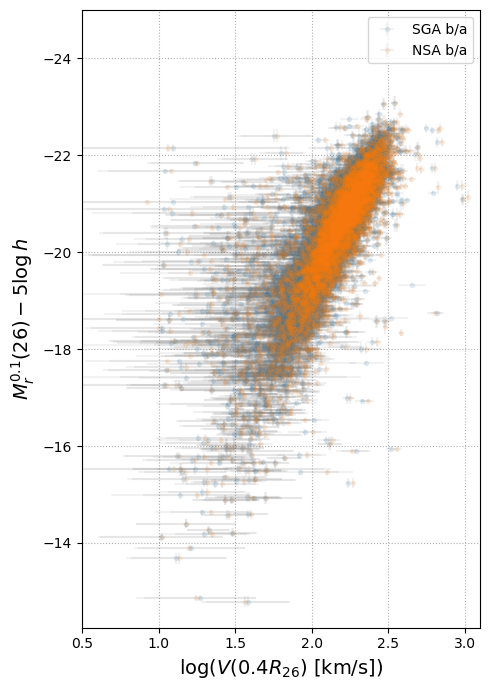

In [12]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.log10(SGA_matched['V_0p4R26']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='SGA b/a')

plt.errorbar(np.log10(SGA_matched['V_0p4R26_NSA']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26_NSA'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='NSA b/a')

plt.legend()

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -25])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

/var/folders/mg/fxh1s24d0n3_r0c39d3gs0g00000gq/T/ipykernel_56114/2914400131.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.plot([np.log10(SGA_matched['V_0p4R26'][i]), np.log10(SGA_matched['V_0p4R26_NSA'][i])],
/var/folders/mg/fxh1s24d0n3_r0c39d3gs0g00000gq/T/ipykernel_56114/2914400131.py:12: RuntimeWarning: divide by zero encountered in log10
  c=cmap(np.abs(np.log10(SGA_matched['V_0p4R26_NSA'][i]/SGA_matched['V_0p4R26'][i]))/0.5))


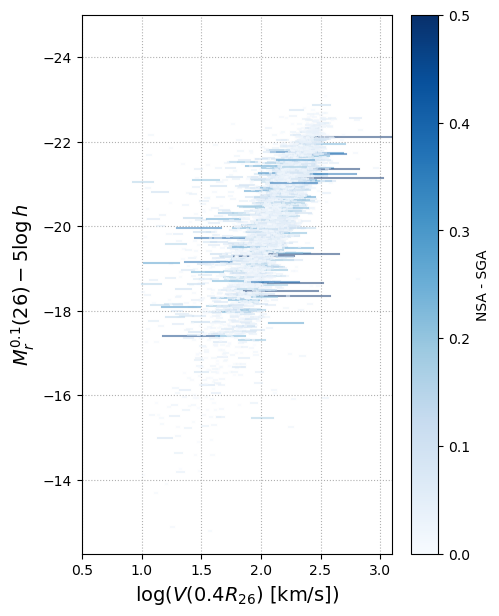

In [41]:
cmap = plt.get_cmap('Blues')

fig, ax = plt.subplots(1,1, figsize=(5,7))

ax.grid(ls=':')

for i in range(len(SGA_matched)):

    plt.plot([np.log10(SGA_matched['V_0p4R26'][i]), np.log10(SGA_matched['V_0p4R26_NSA'][i])], 
             [SGA_matched['R_ABSMAG_SB26'][i], SGA_matched['R_ABSMAG_SB26'][i]], 
             alpha=0.5, 
             c=cmap(np.abs(np.log10(SGA_matched['V_0p4R26_NSA'][i]/SGA_matched['V_0p4R26'][i]))/0.5))

fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 0.5), cmap='Blues'), 
             ax=ax, orientation='vertical', label='NSA - SGA')

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -25])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

# Fit a line to both populations to measure the dispersion

In [13]:
logV0_SGA = np.median(np.log10(SGA_matched['V_0p4R26']))

logV_SGA = np.log10(SGA_matched['V_0p4R26']) - logV0_SGA
logV_err_SGA = np.log10(SGA_matched['V_0p4R26_ERR']) / SGA_matched['V_0p4R26']

Mag = SGA_matched['R_ABSMAG_SB26']
Mag_err = SGA_matched['R_ABSMAG_SB26_ERR']

In [14]:
bounds = [[-20, 0]]                 # Bounds on a (slope)
bounds += [(-30, 0)]                # Bounds on B
bounds += [(0,5)]                   # Bounds on sigma

results = hyperfit_line(logV_SGA, Mag, logV_err_SGA, Mag_err, bounds)

a, b, sig_tfr, cov_tfr, tfr_mcmc_samples, hf_tfr = results

             message: Optimization terminated successfully.
             success: True
                 fun: -10770.390607895373
                   x: [-2.933e+00 -4.285e-01  1.295e-01]
                 nit: 74
                nfev: 3391
          population: [[-2.933e+00 -4.285e-01  1.295e-01]
                       [-2.933e+00 -4.285e-01  1.294e-01]
                       ...
                       [-2.934e+00 -4.286e-01  1.295e-01]
                       [-2.935e+00 -4.288e-01  1.295e-01]]
 population_energies: [-1.077e+04 -1.077e+04 ... -1.077e+04 -1.077e+04]
                 jac: [ 2.212e+00 -7.198e+00 -2.031e+01]


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1316.72it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [26.90482774 26.93792429 31.2684067 ] / 1563.4203350227847


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1322.72it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [30.76043222 31.12959757 30.87495556] / 1556.4798786746544


...

Niterations/Max Iterations:  7000 / 100000
Integrated ACT/Min Convergence Iterations:  [36.99816758 37.02721427 42.81767976] / 2140.8839878214912


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1309.33it/s]


Niterations/Max Iterations:  8000 / 100000
Integrated ACT/Min Convergence Iterations:  [37.25242851 37.36632509 46.87093845] / 2343.5469224358094


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1328.67it/s]

Niterations/Max Iterations:  9000 / 100000
Integrated ACT/Min Convergence Iterations:  [37.99735    38.19983185 49.24159674] / 2462.0798371203678


In [15]:
logV0_NSA = np.median(np.log10(SGA_matched['V_0p4R26_NSA']))

logV_NSA = np.log10(SGA_matched['V_0p4R26_NSA']) - logV0_NSA
logV_err_NSA = np.log10(SGA_matched['V_0p4R26_ERR']) / SGA_matched['V_0p4R26_NSA']

/Users/kdouglass/miniforge3/envs/desi/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [16]:
bounds = [[-20, 0]]                 # Bounds on a (slope)
bounds += [(-30, 0)]                # Bounds on B
bounds += [(0,5)]                   # Bounds on sigma

results_NSA = hyperfit_line(logV_NSA, Mag, logV_err_NSA, Mag_err, bounds)

a_NSA, b_NSA, sig_tfr_NSA, cov_tfr_NSA, tfr_mcmc_samples_NSA, hf_tfr_NSA = results_NSA

             message: Optimization terminated successfully.
             success: True
                 fun: -10510.566607204033
                   x: [-2.953e+00 -4.345e-01  1.346e-01]
                 nit: 66
                nfev: 3035
          population: [[-2.953e+00 -4.345e-01  1.346e-01]
                       [-2.954e+00 -4.347e-01  1.346e-01]
                       ...
                       [-2.957e+00 -4.358e-01  1.347e-01]
                       [-2.952e+00 -4.342e-01  1.347e-01]]
 population_energies: [-1.051e+04 -1.051e+04 ... -1.051e+04 -1.051e+04]
                 jac: [-8.327e-01  2.841e+00 -6.632e-01]


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1304.03it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [28.90996236 29.12290811 28.75071785] / 1456.1454053606958


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1274.23it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [49.28650956 49.67595514 31.7529237 ] / 2483.797756821922


...

Niterations/Max Iterations:  6000 / 100000
Integrated ACT/Min Convergence Iterations:  [33.99459611 34.11130949 39.81608959] / 1990.8044793554704


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1330.95it/s]


Niterations/Max Iterations:  7000 / 100000
Integrated ACT/Min Convergence Iterations:  [36.7250918  36.67894328 45.81909753] / 2290.9548766022017


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1322.71it/s]

Niterations/Max Iterations:  8000 / 100000
Integrated ACT/Min Convergence Iterations:  [35.95073788 35.99869739 46.19992934] / 2309.9964668495054


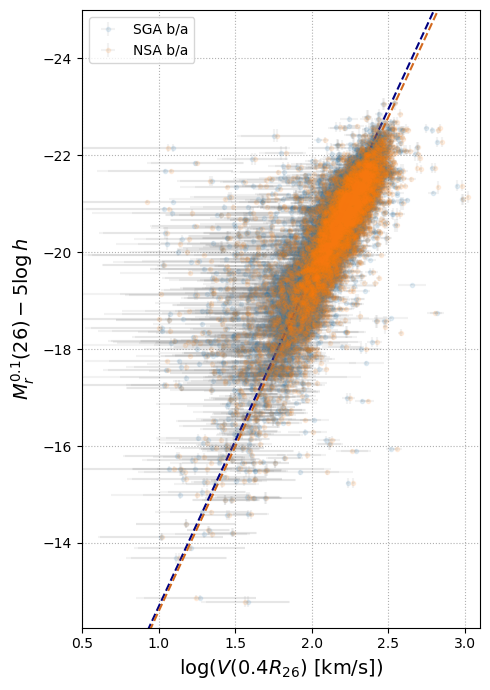

In [17]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.log10(SGA_matched['V_0p4R26']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='SGA b/a')

plt.errorbar(np.log10(SGA_matched['V_0p4R26_NSA']), 
             SGA_matched['R_ABSMAG_SB26'], 
             xerr=0.434*SGA_matched['V_0p4R26_ERR']/SGA_matched['V_0p4R26_NSA'],
             yerr=SGA_matched['R_ABSMAG_SB26_ERR'], 
             fmt='.', 
             alpha=0.1, 
             ecolor='gray', 
             label='NSA b/a')

_logv = np.arange(0, 3, 0.1)

plt.plot(_logv, a*(_logv - logV0_SGA) + b, '--', c='navy')
plt.plot(_logv, a_NSA*(_logv - logV0_NSA) + b_NSA, '--', c='chocolate')

plt.legend()

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -25])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

In [18]:
diff_SGA = np.log10(SGA_matched['V_0p4R26']) - ((SGA_matched['R_ABSMAG_SB26'] - b)/a + logV0_SGA)
diff_NSA = np.log10(SGA_matched['V_0p4R26_NSA']) - ((SGA_matched['R_ABSMAG_SB26'] - b_NSA)/a_NSA + logV0_NSA)

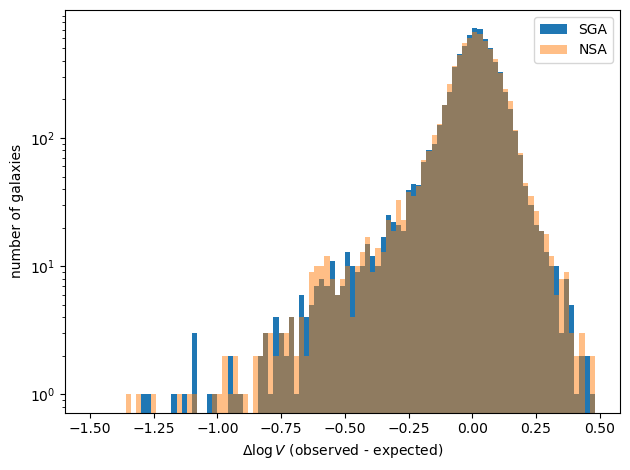

In [27]:
plt.figure(tight_layout=True)

logV_diff_bins = np.arange(-1.5, 0.5, 0.02)

plt.hist(diff_SGA, bins=logV_diff_bins, label='SGA')
plt.hist(diff_NSA, bins=logV_diff_bins, label='NSA', alpha=0.5)

plt.yscale('log')

plt.legend()

plt.xlabel(r'$\Delta \log V$ (observed - expected)')
plt.ylabel('number of galaxies');

In [22]:
print(f'SGA: {np.std(diff_SGA):.2f}')
print(f'NSA: {np.std(diff_NSA):.2f}')

SGA: 0.14
NSA: 0.15
